In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from pycontrails.models.gpat.gpat_clean import GPAT_clean, SimParams, dict_to_dataclass
from dataclasses import asdict
from pycontrails.core import MetDataset
from pycontrails.physics import geo, thermo, units, constants
import pickle
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


In [ ]:
months = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

for m, month in enumerate(months):

    sim_params = {
        "t0_sim": pd.to_datetime("2022-01-01 12:00:00"),  # chemistry start time
        "rt_sim": pd.Timedelta(days=5),  # chemistry runtime
        "ts_sim": pd.Timedelta(seconds=20),  # chemistry time step
        "lat_bounds": (-87.5, 87.5),  # lat bounds [deg]
        "lon_bounds": (-177.5, 177.5),  # lon bounds [deg]
        "alt_bounds": (8000, 13000),  # alt bounds [m]
        "hres_sim": 5,  # horizontal resolution [deg]
        "vres_sim": 1000,  # vertical resolution [m]
        "eastward_wind": 0.0,  # m/s
        "northward_wind": 0.0,  # m/s
        "lagrangian_tendency_of_air_pressure": 0.0,  # m/s
        "species_in": ("NO", "NO2", "CO", "HCHO", "CH3CHO", "C2H4", "C3H6", "C2H2", "BENZENE"),
        "species_out": ("O3", "NO2", "NO", "NO3", "HNO3", "PAN", "HONO", "HO2", "OH","H2O2", 
                        "CO", "HCHO", "CH4"),
        "gpat_path": os.getcwd() +"/",
        "job_id": "global_jan",
        "run_gpat": None
    }

In [3]:
sim_params = dict_to_dataclass(SimParams, sim_params)

In [4]:
gpat = GPAT_clean(sim_params)

In [5]:
gpat.met = gpat.gen_met()
gpat.bg_chem = gpat.gen_bg_chem()

<xarray.DataArray 'bg_chem' (latitude: 36, longitude: 72, level: 9, species: 219)> Size: 41MB
[5108832 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float64 288B -87.5 -82.5 -77.5 ... 77.5 82.5 87.5
  * longitude  (longitude) float64 576B -177.5 -172.5 -167.5 ... 172.5 177.5
  * level      (level) float64 72B 962.0 861.0 759.0 658.0 ... 353.0 251.0 150.5
    month      int64 8B 0
  * species    (species) <U10 9kB 'O1D' 'O' 'OH' ... 'CH3O2NO2' 'EMPOA' 'P2007'


In [6]:
gpat.met

MetDataset with data:

<xarray.Dataset> Size: 4MB
Dimensions:                              (longitude: 72, latitude: 36,
                                          level: 6, time: 3)
Coordinates:
  * longitude                            (longitude) float64 576B -177.5 ... ...
  * latitude                             (latitude) float64 288B -87.5 ... 87.5
  * level                                (level) float64 48B 165.1 ... 356.0
  * time                                 (time) datetime64[ns] 24B 2022-01-01...
    air_pressure                         (level) float64 48B 1.651e+04 ... 3....
    altitude                             (level) float64 48B 1.3e+04 ... 8e+03
    month                                int64 8B 0
Data variables:
    eastward_wind                        (longitude, latitude, level, time) float64 373kB dask.array<chunksize=(72, 36, 6, 3), meta=np.ndarray>
    northward_wind                       (longitude, latitude, level, time) float64 373kB dask.array<chunksize=(72, 36, 6, 3), meta=np.ndarray>
    lagrangian_tendency_of_air_pressure  (longitude, latitude, level, time) float64 373kB dask.array<chunksize=(72, 36, 6, 3), meta=np.ndarray>
    air_temperature                      (latitude, longitude, level, time) float64 373kB ...
    H2O                                  (latitude, longitude, level, time) float64 373kB ...
    specific_humidity                    (latitude, longitude, level, time) float64 373kB ...
    relative_humidity                    (latitude, longitude, level, time) float64 373kB ...
    M                                    (latitude, longitude, level, time) float64 373kB ...
    O2                                   (latitude, longitude, level, time) float64 373kB ...
    N2                                   (latitude, longitude, level, time) float64 373kB ...
    sza                                  (latitude, longitude, time) float64 62kB ...

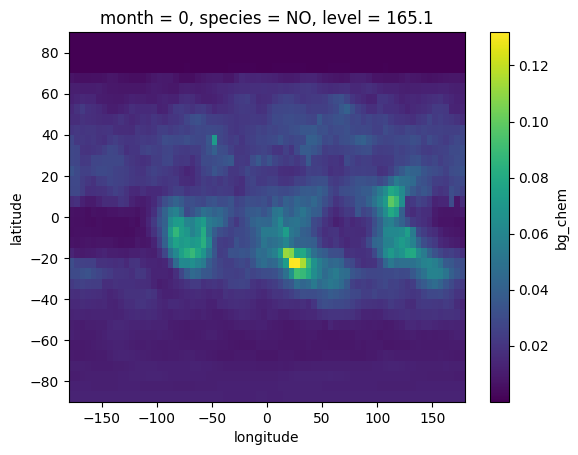

In [7]:
gpat.bg_chem['bg_chem'].sel(species='NO').sel(level=140, method='nearest').plot()

In [8]:
gpat.chem = gpat.run_boxm()

 global_jan                                                                                                                                                                                                                                                      
 DTS:    20.0000000    
 SPECIES_OUT_NUM:            6           4           8           5          14         198          13           9           3          12          11          39          21
Chunking the dataset
Set coords
Set index
Unstack the dataset
Compute the result


In [9]:
gpat.gen_outputs()

Generating outputs...
Saving chem dataset to netCDF file...
Done!


In [10]:
# ax1 = plt.axes(projection=ccrs.PlateCarree())
# ax1.coastlines()
# #NO2.plot(ax=ax1)

# del_NO2 = NO2_equiv - NO2

# NO2_equiv.plot(ax=ax1, cmap="inferno_r", vmin=0.5, vmax=3)

#NO2_equiv.plot(ax=ax1)
#ax1.stock_img()